**Motion descriptors(features) to be Analyzed:**  

1.SSIM (Structured Similarity Index Measure)
Measures frame to frame structural change/deformation reflecting larvae body movement changes   
2.1Mean Displacement  
Measured by optical-flow magnitude, it represents average larval displacement activity level.  
2.2Max Displacement  
max displacement represents maximum larval displacement activity
2.3 Min Displacement  
represents the minimum larval displacement activity


SSIM was usede to detect motion just like Nasr et.295 Abdel-Salam Nasr et al. (2017)

The mean displacement was used to measure the average size of mo-310
tion vectors between the consecutive pixels of frames calculated using the311
Farneback Optical Flow algorithm based on the studies by Shah and Xuezhi312
(2021), Alfarano et al. (2024), Sun et al. (2024).Before the calculation of313
optical flow, the edges were identified using the Canny Edge Detection al-314
gorithm in order to constrain the larvae motion vectors only to the regions315
of structural importance, hence avoiding any noise just like (Zangana et al.,316
2024), Kannan (2024), Selvakumar and Thangaraju (2024). The average of317
the magnitude of motion vectors was calculated using the Euclidean distance318
for all edge points in a video similar to (Shah and Xuezhi, 2021).

By refering to, Alfarano et al. (2024), Sun et al. (2024), (Zangana et al.,321
2024), Maximum Displacement cap-322
tured the highest value of motion vectors calculated based on the Farneback323
Optical Flow method, but limited to those within edge zones determined by324
Canny Edge Detection. This measure represented the maximum intensity of325
motion that could be recorded throughout a sequence of images, thus rep-326
resenting sudden or fast motion. The emphasis here as well was on vectors327
calculated from edges, allowing for an elimination of noise and hence making328
it highly sensitive to extreme motion .

Similar to previous subsections above 3.3.2 and 3.3.3 above, Minimum dis-331
placement in this case here refered to the lowest magnitude of motion vectors332
obtained from Farneback Optical Flow technique, constrained to edge regions333
detected by Canny Edge Detection, just as illustrated by Shah and Xuezhi334
(2021) and Zangana et al. (2024) techniques. It therefore reflected the small-335
est detectable motion intensity within a frame sequence, this represented336
time when there is little to no motion at all.

Importing libralies

In [ ]:
#  IMPORTS
import cv2
import numpy as np
import os
import pandas as pd
from google.colab import drive
import zipfile
from skimage.metrics import structural_similarity as ssim
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, levene
import matplotlib.pyplot as plt
import seaborn as sns

defining variables and optical paramaters\

In [ ]:
"""Global variables and configurations"""
NUM_FRAMES = 40
MAX_FRAMES = 120
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
SSIM_THRESHOLD = 80
BALANCED_N = 120 #50 #120

# Farneback optical flow parameters
FLOW_PARAMS = dict(
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

**importing data from drive**

Data source link:https://drive.google.com/file/d/1AZ7FiMwkx1dhTBecEeUTTP3FY-RM5wRH/view?usp=sharing

In [ ]:
#  MOUNT DRIVE AND EXTRACT ZIP
drive.mount('/content/drive')
zip_folder = 'drive/My Drive/Colab Notebooks_videoAnalytics/phse6_all_vids.zip'
with zipfile.ZipFile(zip_folder, 'r') as zip_ref:
    zip_ref.extractall('')
print("Extraction complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction complete.


meta data source link: https://docs.google.com/spreadsheets/d/1YdHcp9ckljL72QLSUfiGGvRk8bEKR_r9/edit?usp=sharing&ouid=103311963141763746786&rtpof=true&sd=true

In [ ]:
#  LOAD METADATA
metadata_file = 'neg_pm _neg_nm_Mb_strength_densities_sig_test_meta_phse6.xlsx'
metadata = pd.read_excel(metadata_file)

In [ ]:
metadata.head()

,larvae_Id,video_name,tag
0,LV1,"larvae_temp,25_7°C,03-07-2025,09-57-35AM.mp4",strong_positive
1,NaN,"larvae_temp,25_8°C,03-07-2025,09-57-44AM.mp4",strong_positive
2,NaN,"larvae_temp,25_7°C,03-07-2025,09-57-52AM.mp4",strong_positive
3,NaN,"larvae_temp,25_7°C,03-07-2025,09-57-59AM.mp4",strong_positive
4,NaN,"larvae_temp,25_7°C,03-07-2025,09-58-07AM.mp4",strong_positive


In [ ]:
metadata.tail()

,larvae_Id,video_name,tag
795,NaN,"larvae_temp,26_7°C,03-07-2025,03-41-58PM.mp4",negative_nm
796,NaN,"larvae_temp,26_6°C,03-07-2025,03-42-06PM.mp4",negative_nm
797,NaN,"larvae_temp,26_7°C,03-07-2025,03-42-14PM.mp4",negative_nm
798,NaN,"larvae_temp,26_5°C,03-07-2025,03-42-21PM.mp4",negative_nm
799,NaN,"larvae_temp,26_8°C,03-07-2025,03-42-29PM.mp4",negative_nm


In [ ]:
#  FRAME PREPROCESSING
def preprocess_frame(frame):
    h, w = frame.shape[:2]
    min_dim = min(h, w)
    y, x = (h - min_dim)//2, (w - min_dim)//2
    frame = frame[y:y+min_dim, x:x+min_dim]
    frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    return gray.astype("float32") / 255.0

In [ ]:

#  EXTRACT ALL FRAMES
def extract_all_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while len(frames) < MAX_FRAMES:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(preprocess_frame(frame))
    cap.release()
    return np.array(frames)

#  SEGMENT FRAMES
def segment_frames(frames, num_segments=NUM_FRAMES):
    return np.array_split(np.arange(len(frames)), num_segments)

#  SSIM-BASED DIVERSE SAMPLING
def sample_diverse_frames(frames, segments):
    selected = []
    prev = None

    for seg in segments:
        indices = np.random.choice(seg, size=len(seg), replace=True)
        best, best_sim = None, 1.0

        for i in indices:
            f = frames[i]

            if prev is None:
                selected.append(f)
                prev = f
                break

            sim = ssim(prev, f, data_range=1.0)

            if sim < SSIM_THRESHOLD and sim < best_sim:
                best_sim = sim
                best = f

        if best is not None:
            selected.append(best)
            prev = best
        else:
            rand_idx = np.random.choice(seg)
            selected.append(frames[rand_idx])
            prev = frames[rand_idx]

    return np.array(selected)

In [ ]:
#  OPTICAL FLOW + EDGE MASK FEATURES
def compute_motion_features(frames):
    ssim_motion_vals = []
    mean_disp_vals = []
    max_disp_vals = []
    min_disp_vals = []

    for i in range(1, len(frames)):
        prev = frames[i-1]
        curr = frames[i]

        # SSIM motion
        ssim_motion_vals.append(1 - ssim(prev, curr, data_range=1.0))

        # Optical flow
        prev_u = (prev * 255).astype(np.uint8)
        curr_u = (curr * 255).astype(np.uint8)
        edges = cv2.Canny(prev_u, 80, 150)
        flow = cv2.calcOpticalFlowFarneback(prev_u, curr_u, None, **FLOW_PARAMS)
        vectors = flow[edges > 0]

        if len(vectors) > 0:
            mag = np.linalg.norm(vectors, axis=1)
            mean_disp_vals.append(np.mean(mag))
            max_disp_vals.append(np.max(mag))
            min_disp_vals.append(np.min(mag))
        else:
            mean_disp_vals.append(0)
            max_disp_vals.append(0)
            min_disp_vals.append(0)

    return (
        np.mean(ssim_motion_vals),
        np.mean(mean_disp_vals),
        np.mean(max_disp_vals),
        np.mean(min_disp_vals)
    )

In [ ]:

#  BALANCE DATASET
def get_balanced(metadata):
    s_pos = metadata[metadata['tag'].str.lower() == 'strong_positive'].sample(BALANCED_N, random_state=42)
    w_pos = metadata[metadata['tag'].str.lower() == 'weak_positive'].sample(BALANCED_N, random_state=42)
    neg_nm = metadata[metadata['tag'].str.lower() == 'negative_nm'].sample(BALANCED_N, random_state=42)
    neg_pm = metadata[metadata['tag'].str.lower() == 'negative_pm'].sample(BALANCED_N, random_state=42)
    return pd.concat([s_pos, w_pos, neg_pm, neg_nm]).sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
#  MAIN PIPELINE
records = []
metadata_bal = get_balanced(metadata)
video_dir = 'phse6_all_vids'

for _, row in metadata_bal.iterrows():
    name = row['video_name']
    label = row['tag'].capitalize()
    path = os.path.join(video_dir, name)

    try:
        frames = extract_all_frames(path)
        if len(frames) < NUM_FRAMES:
            continue

        segments = segment_frames(frames, NUM_FRAMES)
        sampled = sample_diverse_frames(frames, segments)

        ssim_score, mean_disp, max_disp, min_disp = compute_motion_features(sampled)

        records.append({
            "VideoID": name,
            "Infection": label,
            "SSIM_Motion": ssim_score,
            "Mean_Displacement": mean_disp,
            "Max_Displacement": max_disp,
            "Min_Displacement": min_disp
        })

    except Exception as e:
        print("Skipped:", name, e)

In [ ]:

df_motion = pd.DataFrame(records)

In [ ]:
df_motion.to_csv("hybrid_motion_final_edgeflow_mb_positives.csv", index=False)

df_motion.head()

,VideoID,Infection,SSIM_Motion,Mean_Displacement,Max_Displacement,Min_Displacement
0,"larvae_temp,26_1°C,03-07-2025,10-33-34AM.mp4",Strong_positive,0.005520,0.064265,0.304754,0.001614
1,"larvae_temp,27_0°C,03-07-2025,02-33-49PM.mp4",Negative_nm,0.006741,0.067050,0.393518,0.001134
2,"larvae_temp,26_8°C,03-07-2025,02-33-18PM.mp4",Negative_nm,0.006325,0.064370,0.300729,0.001411
3,"larvae_temp,26_6°C,03-07-2025,10-44-50AM.mp4",Negative_pm,0.005766,0.059132,0.273429,0.001751
4,"larvae_temp,26_9°C,03-07-2025,02-47-54PM.mp4",Negative_nm,0.004357,0.057231,0.237872,0.001903


In [ ]:
print("Weak_positive samples:", len(df_motion[df_motion['Infection']=='Weak_positive']))
print("Strong_positive samples:", len(df_motion[df_motion['Infection']=='Strong_positive']))
print("Negative samples_Neg Mothers:", len(df_motion[df_motion['Infection']=='Negative_nm']))
print("Negative samples_Pos Mothers:", len(df_motion[df_motion['Infection']=='Negative_pm']))

Weak_positive samples: 120
Strong_positive samples: 120
Negative samples_Neg Mothers: 113
Negative samples_Pos Mothers: 120


DESCRIPTIVE STATISTICS_ EDA

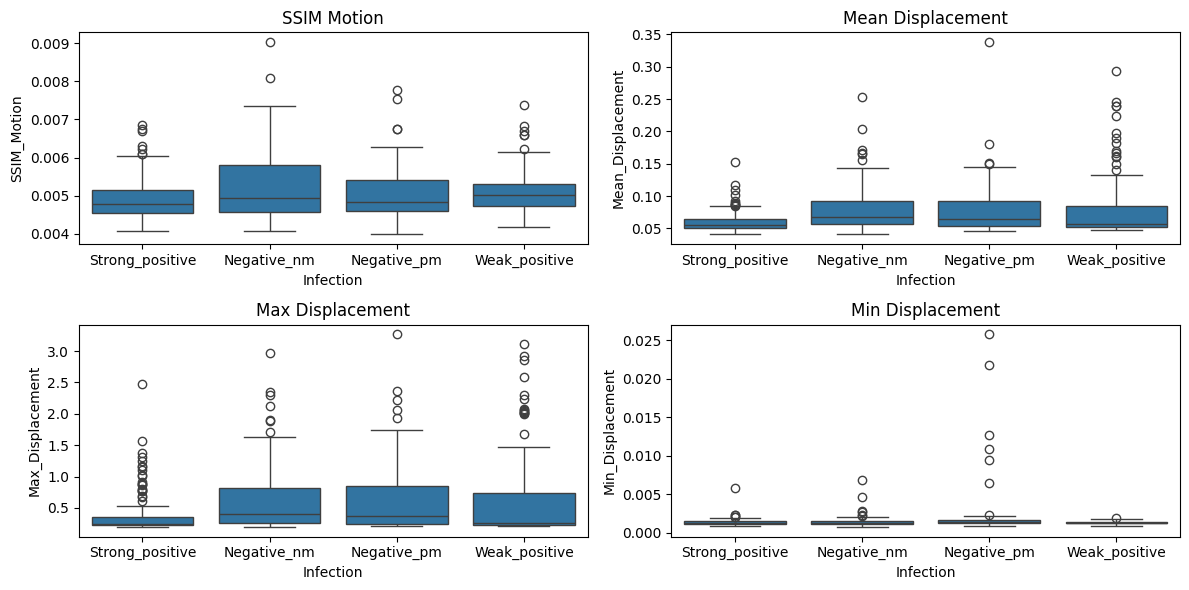

In [ ]:
#  VISUALIZATION
features = ['SSIM_Motion','Mean_Displacement','Max_Displacement', 'Min_Displacement']
feature_names = ['SSIM Motion','Mean Displacement','Max Displacement', 'Min Displacement']

plt.figure(figsize=(12, 6))
for i, f in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='Infection', y=f, data=df_motion)
    plt.title(feature_names[i])
plt.tight_layout()
plt.show()

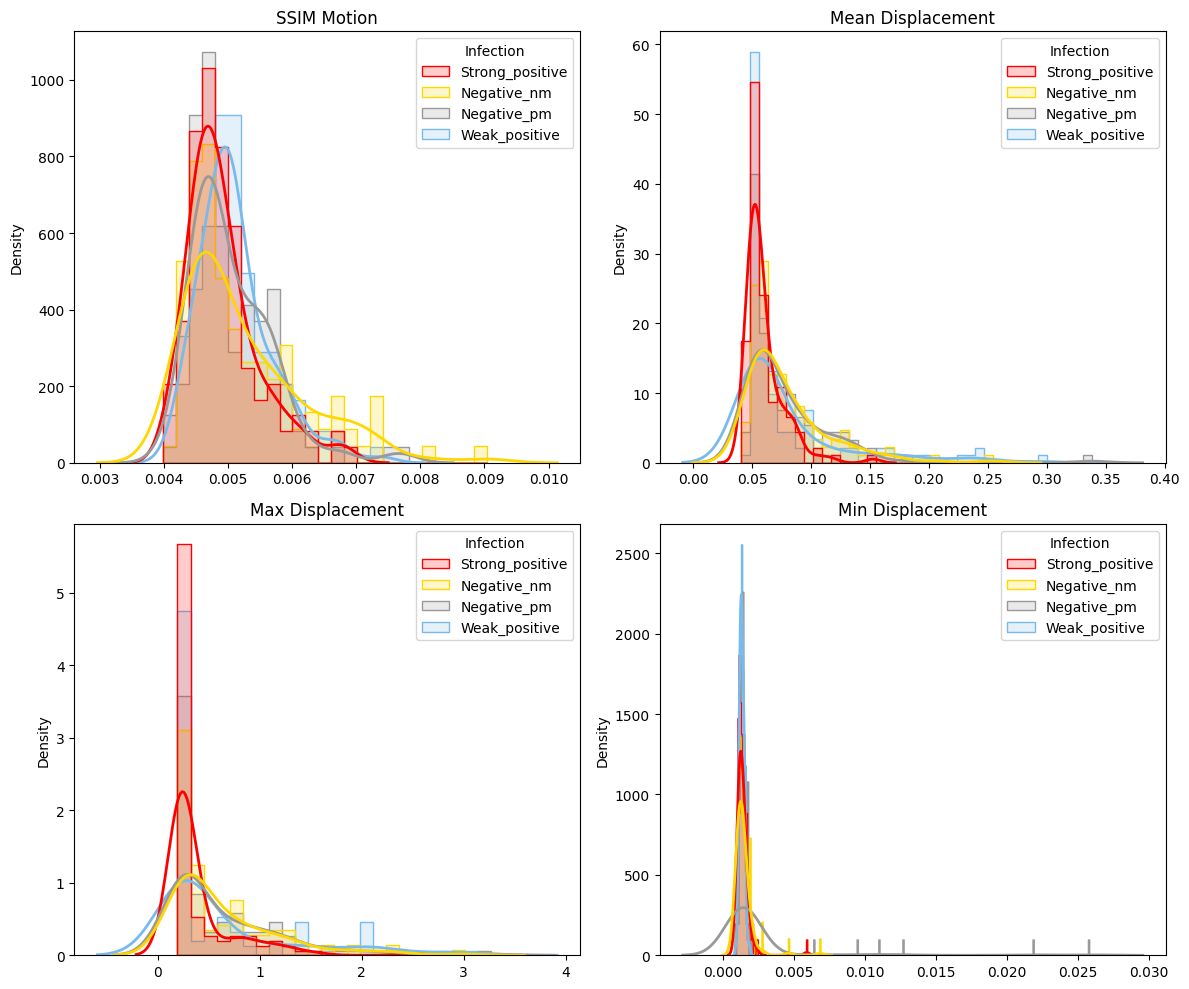

In [ ]:
#Histograms with custom hue colors and KDE matching
plt.figure(figsize=(12, 10))

# customizing palette for all three infection categories
palette = {
    'Weak_positive': '#79BAEC',   # Denim Blue
    'Strong_positive': '#FF0000',#'#FFA07A', # Light Salmon
    'Negative_pm': '#999999',            # Gray
    'Negative_nm': '#FFD700',
    #'Nm_negative': '#90EE90'


}

for i, f in enumerate(features):
    plt.subplot(2, 2, i+1)

    # Plot histogram without KDE first (semi-transparent)
    sns.histplot(
        data=df_motion,
        x=f,
        hue='Infection',
        kde=False,            # Disable KDE for bars
        element='step',
        stat='density',
        common_norm=False,
        palette=palette,
        alpha=0.2
    )

    # Plot KDE curves separately with the same colors
    for label, color in palette.items():
        subset = df_motion[df_motion['Infection'] == label][f]
        sns.kdeplot(
            subset,
            color=color,
            lw=2,              # Line width
            label=None         # No extra legend entry
        )

    plt.title(feature_names[i])
    plt.xlabel('')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()


INFERENTIAL STATISTICS

In [ ]:
!pip install scikit-posthocs


In [ ]:
## subsetting to only include the required groups to be used in th test
df2_motion = df_motion[df_motion['Infection'].isin(['Strong_positive', 'Weak_positive', 'Negative_pm'])]
df2_motion

,VideoID,Infection,SSIM_Motion,Mean_Displacement,Max_Displacement,Min_Displacement
0,"larvae_temp,26_1°C,03-07-2025,10-33-34AM.mp4",Strong_positive,0.005520,0.064265,0.304754,0.001614
3,"larvae_temp,26_6°C,03-07-2025,10-44-50AM.mp4",Negative_pm,0.005766,0.059132,0.273429,0.001751
5,"larvae_temp,25_5°C,03-07-2025,10-09-10AM.mp4",Weak_positive,0.004916,0.051661,0.232734,0.001232
6,"larvae_temp,27_2°C,03-07-2025,01-38-08PM.mp4",Negative_pm,0.004690,0.064765,0.300296,0.001523
8,"larvae_temp,27_9°C,03-07-2025,12-48-30PM.mp4",Strong_positive,0.005166,0.088904,1.107744,0.001424
...,...,...,...,...,...,...
468,"larvae_temp,28_2°C,03-07-2025,12-48-23PM.mp4",Strong_positive,0.004165,0.051414,0.226444,0.001245
469,"larvae_temp,26_2°C,03-07-2025,10-39-59AM.mp4",Strong_positive,0.004822,0.050751,0.223148,0.001248
470,"larvae_temp,28_3°C,03-07-2025,01-02-09PM.mp4",Negative_pm,0.004128,0.055072,0.240660,0.001844
471,"larvae_temp,25_6°C,03-07-2025,10-01-59AM.mp4",Negative_pm,0.005033,0.050836,0.225850,0.001101


STATISTICS

In [ ]:
#show eunique groups in infection column
df2_motion['Infection'].unique()

array(['Strong_positive', 'Negative_pm', 'Weak_positive'], dtype=object)

In [ ]:
#sum of uneque groups in infection column
df2_motion['Infection'].value_counts()

,count
Infection,
Strong_positive,120
Negative_pm,120
Weak_positive,120


In [ ]:
# THREE-GROUP STATISTICAL ANALYSIS WITH DUNN POST-HOC

from scipy.stats import f_oneway, kruskal, shapiro, levene
import scikit_posthocs as sp
import pandas as pd

results = []
dunn_results_store = {}  # Store Dunn post-hoc results to print later

for f, name in zip(features, feature_names):

    # Split data by groups
    s_pos = df2_motion[df2_motion['Infection']=='Strong_positive'][f]
    w_pos = df2_motion[df2_motion['Infection']=='Weak_positive'][f]
    neg_pm = df2_motion[df2_motion['Infection']=='Negative_pm'][f]

    #ASSUMPTION 1: NORMALITY CHECK
    p_norm_s = shapiro(s_pos)[1]
    p_norm_w = shapiro(w_pos)[1]
    p_norm_neg_pm = shapiro(neg_pm)[1]

    all_normal = (p_norm_s > 0.05) and (p_norm_w > 0.05) and (p_norm_neg_pm > 0.05)

    # DECIDE TEST BASED ON NORMALITY
    if all_normal:
        # If normal, check variance equality
        p_var = levene(s_pos, w_pos, neg_pm)[1]
        equal_var = p_var > 0.05

        if equal_var:
            stat, p = f_oneway(s_pos, w_pos, neg_pm)
            test_used = "One-Way ANOVA"
        else:
            stat, p = f_oneway(s_pos, w_pos, neg_pm)
            test_used = "ANOVA (Unequal Variance - Caution)"

        posthoc = "Use Tukey post-hoc if significant"

    else:
        # Non-normal → Kruskal-Wallis
        stat, p = kruskal(s_pos, w_pos, neg_pm)
        test_used = "Kruskal-Wallis H-test"
        p_var = None

        # DUNN POST-HOC IF SIGNIFICANT
        if p < 0.05:
            dunn = sp.posthoc_dunn(
                df2_motion,
                val_col=f,
                group_col='Infection',
                p_adjust='bonferroni'
            )
            dunn_results_store[name] = dunn  # Store for printing later
            posthoc = "Dunn pairwise performed (see below)"
        else:
            posthoc = "Not significant – no post-hoc needed"

    # --------- STORE RESULTS ---------
    results.append({
        "Feature": name,
        "Test Used": test_used,
        "Mean Strong_Pos": s_pos.mean(),
        "Median Strong_Pos": s_pos.median(),
        "Mean Weak_Pos": w_pos.mean(),
        "Median Weak_Pos": w_pos.median(),
        "Mean Neg_Pm": neg_pm.mean(),
        "Median Neg_Pm": neg_pm.median(),
        "Normality p (Strong_Pos)": p_norm_s,
        "Normality p (Weak_Pos)": p_norm_w,
        "Normality p (Pm_Neg)": p_norm_neg_pm,
        "Variance Homogeneity p": p_var,
        "Final p-value": p,
        "Post-hoc action": posthoc
    })

#  CREATING a SUMMARY DATAFRAME
results_df = pd.DataFrame(results)

print("\nFINAL THREE-GROUP STATISTICAL SUMMARY:\n")
print(results_df)

#PRINT DUNN POST-HOC RESULTS AFTER SUMMARy
for feature_name, dunn_df in dunn_results_store.items():
    print(f"\nDunn Post-hoc for: {feature_name}")
    print(dunn_df)



FINAL THREE-GROUP STATISTICAL SUMMARY:

             Feature              Test Used  Mean Strong_Pos  \
0        SSIM Motion  Kruskal-Wallis H-test         0.004918   
1  Mean Displacement  Kruskal-Wallis H-test         0.060246   
2   Max Displacement  Kruskal-Wallis H-test         0.395073   
3   Min Displacement  Kruskal-Wallis H-test         0.001386   

   Median Strong_Pos  Mean Weak_Pos  Median Weak_Pos  Mean Neg_Pm  \
0           0.004784       0.005114         0.005014     0.005051   
1           0.055022       0.079745         0.056737     0.077924   
2           0.240874       0.647647         0.259499     0.626801   
3           0.001310       0.001335         0.001324     0.002092   

   Median Neg_Pm  Normality p (Strong_Pos)  Normality p (Weak_Pos)  \
0       0.004848              1.436593e-07            2.285434e-06   
1       0.064373              1.380904e-12            1.716683e-15   
2       0.372402              5.506330e-17            4.766638e-15   
3       0.00

In [ ]:
#results table
results_df

,Feature,Test Used,Mean Strong_Pos,Median Strong_Pos,Mean Weak_Pos,Median Weak_Pos,Mean Neg_Pm,Median Neg_Pm,Normality p (Strong_Pos),Normality p (Weak_Pos),Normality p (Pm_Neg),Variance Homogeneity p,Final p-value,Post-hoc action
0,SSIM Motion,Kruskal-Wallis H-test,0.004918,0.004784,0.005114,0.005014,0.005051,0.004848,1.436593e-07,2.285434e-06,4.930007e-08,None,0.006371,Dunn pairwise performed (see below)
1,Mean Displacement,Kruskal-Wallis H-test,0.060246,0.055022,0.079745,0.056737,0.077924,0.064373,1.380904e-12,1.716683e-15,2.463964e-14,None,0.000004,Dunn pairwise performed (see below)
2,Max Displacement,Kruskal-Wallis H-test,0.395073,0.240874,0.647647,0.259499,0.626801,0.372402,5.506330e-17,4.766638e-15,8.789683e-13,None,0.000012,Dunn pairwise performed (see below)
3,Min Displacement,Kruskal-Wallis H-test,0.001386,0.001310,0.001335,0.001324,0.002092,0.001392,5.238461e-18,2.147175e-01,7.193829e-22,None,0.000085,Dunn pairwise performed (see below)


In [ ]:
#save results_df to csv file
results_df.to_csv("hybrid_motion_final_edgeflow_mb_positives_statistic_results.csv", index=False)


**REFERENCES**

M. Abdel-Salam Nasr, M. F. AlRahmawy, A. Tolba, Multi-scale struc-
tural similarity index for motion detection, Journal of King Saud Uni-
versity - Computer and Information Sciences 29 (3) (2017) 399–409.
doi:https://doi.org/10.1016/j.jksuci.2016.02.004.
URL https://www.sciencedirect.com/science/article/pii/
S1319157816300088

H. Abbas Khalaf, A. Tolba, M. Rashid, Event triggered intelligent video
recording system using ms-ssim for smart home security, Ain Shams En-
gineering Journal 9 (4) (2018) 1527–1533. doi:https://doi.org/
10.1016/j.asej.2016.10.001.
URL https://www.sciencedirect.com/science/article/pii/
S2090447916301435  

S. T. H. Shah, X. Xuezhi, Traditional and modern strategies for optical1157
flow: an investigation, SN Applied Sciences 3 (2021) 289. URL: https:1158
//doi.org/10.1007/s42452-021-04227-x.1159  

A. Alfarano, L. Maiano, L. Papa, I. Amerini, Estimating optical flow: A1160
comprehensive review of the state of the art, Computer Vision and Image1161
Understanding 249 (2024) 104160. URL: https://www.sciencedirect.1162
com/science/article/pii/S1077314224002418. doi:https://doi.org/1163
10.1016/j.cviu.2024.104160.1164  

A. N. R. Kannan, Defective edge detection using cascaded ensemble canny1177
operator, arXiv preprint arXiv:2411.14868 (2024). URL: https://doi.1178
org/10.48550/arXiv.2411.14868.1179  

A. A. Selvakumar, P. Thangaraju, Brain tumour edge detection using an1180
enhanced canny edge detection algorithm, International Journal of Com-1181
putational Biology and Drug Design 16 (2024) 167–183. URL: https:1182
//doi.org/10.1504/IJCBDD.2024.142283.1183  

H. M. Zangana, A. K. Mohammed, F. M. Mustafa, Advancements in edge1173
detection techniques for image enhancement: A comprehensive review,1174
International Journal of Artificial Intelligence & Robotics (IJAIR) 6 (2024)1175
29–39. URL: https://doi.org/10.25139/ijair.v6i1.8217.1176
